In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
transactions = pd.read_csv("fraud_transactions.csv", header=1)
customers = pd.read_csv("fraud_customers.csv", header=1)
fraud_labels = pd.read_csv("fraud_fraud_labels.csv", header=1)

In [6]:
print(transactions.columns)
print(customers.columns)
print(fraud_labels.columns)

Index(['tx_id', 'customer_id', 'amount', 'timestamp', 'merchant_category',
       'Unnamed: 5'],
      dtype='object')
Index(['customer_id', 'age', 'income', 'segment'], dtype='object')
Index(['tx_id', 'is_fraud'], dtype='object')


In [7]:
transactions.drop(columns=['Unnamed: 5'], inplace=True)

In [8]:
df = transactions.merge(customers, on="customer_id")
df = df.merge(fraud_labels, on="tx_id")

In [9]:
df.head()

,tx_id,customer_id,amount,timestamp,merchant_category,age,income,segment,is_fraud
0,TX003996,C0014,2312.19,2024-06-22 16:36:50,Travel,18,23653,Student,0
1,TX002547,C0367,2303.27,2024-09-08 08:03:53,Travel,40,17155,Student,0
2,TX002143,C0471,2291.00,2024-12-27 10:26:28,Travel,34,54590,Standard,0
3,TX004351,C0442,2254.92,2024-01-01 00:48:32,Travel,37,50462,Standard,1
4,TX005050,C0327,2068.52,2024-04-19 06:15:04,Travel,51,35070,Basic,0


In [10]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   tx_id              8000 non-null   object        
 1   customer_id        8000 non-null   object        
 2   amount             8000 non-null   float64       
 3   timestamp          8000 non-null   datetime64[ns]
 4   merchant_category  8000 non-null   object        
 5   age                8000 non-null   int64         
 6   income             8000 non-null   int64         
 7   segment            8000 non-null   object        
 8   is_fraud           8000 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 562.6+ KB


In [12]:
Q1 = df["amount"].quantile(0.25)
Q3 = df["amount"].quantile(0.75)

print(Q1)
print(Q3)

53.77
181.8


In [20]:
IQR = Q3 - Q1
print(IQR)

128.03


In [21]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound)
print(upper_bound)

-138.275
373.845


In [15]:
df["iqr_anomaly"] = (
    (df["amount"] < lower_bound) |
    (df["amount"] > upper_bound)
).astype(int)

In [22]:
df[["amount", "iqr_anomaly"]].head()

,amount,iqr_anomaly
0,2312.19,1
1,2303.27,1
2,2291.00,1
3,2254.92,1
4,2068.52,1


In [ ]:
#IQR detects only unusually high transaction amounts. It misses many fraud cases with normal amounts, resulting in a low fraud recall (20%).

In [23]:
from sklearn.metrics import classification_report

In [24]:
print(classification_report(df["is_fraud"], df["iqr_anomaly"]))

              precision    recall  f1-score   support

           0       0.94      0.89      0.92      7503
           1       0.11      0.20      0.15       497

    accuracy                           0.85      8000
   macro avg       0.53      0.55      0.53      8000
weighted avg       0.89      0.85      0.87      8000



In [25]:
from scipy import stats

In [26]:
df["z_score"] = np.abs(stats.zscore(df["amount"]))

In [27]:
df[["amount", "z_score"]].head()

,amount,z_score
0,2312.19,10.255018
1,2303.27,10.212369
2,2291.00,10.153703
3,2254.92,9.981194
4,2068.52,9.089961


In [28]:
df["zscore_anomaly"] = (df["z_score"] > 3).astype(int)

In [29]:
df["zscore_anomaly"].value_counts()

zscore_anomaly
0    7818
1     182
Name: count, dtype: int64

In [30]:
from sklearn.metrics import classification_report

print(classification_report(df["is_fraud"], df["zscore_anomaly"]))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      7503
           1       0.21      0.08      0.11       497

    accuracy                           0.92      8000
   macro avg       0.58      0.53      0.54      8000
weighted avg       0.90      0.92      0.91      8000



In [ ]:
#Z-Score produces fewer false positives but misses most fraud cases because it relies only on transaction amount.

In [31]:
df["hour"] = df["timestamp"].dt.hour

In [32]:
df["is_weekend"] = (df["timestamp"].dt.dayofweek >= 5).astype(int)

In [33]:
df["is_night"] = (df["hour"] < 6).astype(int)

In [34]:
df["category_encoded"] = df["merchant_category"].astype("category").cat.codes

In [35]:
df["income_ratio"] = df["amount"] / df["income"]

In [36]:
features = [
    "amount",
    "hour",
    "is_weekend",
    "is_night",
    "category_encoded",
    "income_ratio"
]

In [37]:
X = df[features]

In [38]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    contamination=0.0621,
    random_state=42
)

In [39]:
df["iforest_anomaly"] = (
    model.fit_predict(X) == -1
).astype(int)

In [40]:
from sklearn.metrics import classification_report

print(classification_report(df["is_fraud"], df["iforest_anomaly"]))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      7503
           1       0.13      0.13      0.13       497

    accuracy                           0.89      8000
   macro avg       0.54      0.54      0.54      8000
weighted avg       0.89      0.89      0.89      8000



In [ ]:
#Isolation Forest provides a balanced approach by considering multiple features, but its fraud detection performance is still limited, with both precision and recall around 13%.

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

In [42]:
features = [
    "amount",
    "hour",
    "is_weekend",
    "is_night",
    "category_encoded",
    "income_ratio"
]

X = df[features]
y = df["is_fraud"]

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [44]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
model = LogisticRegression(
    class_weight="balanced",
    random_state=42
)

In [46]:
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [47]:
y_pred = model.predict(X_test_scaled)

In [48]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.67      0.79      1501
           1       0.09      0.48      0.15        99

    accuracy                           0.66      1600
   macro avg       0.52      0.58      0.47      1600
weighted avg       0.90      0.66      0.75      1600



In [ ]:
#Logistic Regression detected the most fraud cases (Recall = 48%), but produced more false positives, resulting in lower accuracy.

In [49]:
from sklearn.ensemble import RandomForestClassifier

In [50]:
features = [
    "amount",
    "hour",
    "is_weekend",
    "is_night",
    "category_encoded",
    "income_ratio"
]

X = df[features]
y = df["is_fraud"]

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [52]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

In [53]:
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [54]:
y_pred = model.predict(X_test)

In [55]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1501
           1       0.00      0.00      0.00        99

    accuracy                           0.94      1600
   macro avg       0.47      0.50      0.48      1600
weighted avg       0.88      0.94      0.91      1600



In [ ]:
#Despite its high accuracy, Random Forest failed to identify fraud cases because of the severe class imbalance.

In [58]:
from xgboost import XGBClassifier

In [59]:
!pip install xgboost

In [60]:
model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [61]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [62]:
y_pred = model.predict(X_test)

In [63]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96      1501
           1       0.08      0.01      0.02        99

    accuracy                           0.93      1600
   macro avg       0.51      0.50      0.49      1600
weighted avg       0.89      0.93      0.91      1600



In [ ]:
#Despite its high accuracy, XGBoost failed to identify most fraud cases due to class imbalance.

In [66]:
import shap

In [65]:
!pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [67]:
explainer = shap.TreeExplainer(model)

In [68]:
shap_values = explainer.shap_values(X_test)

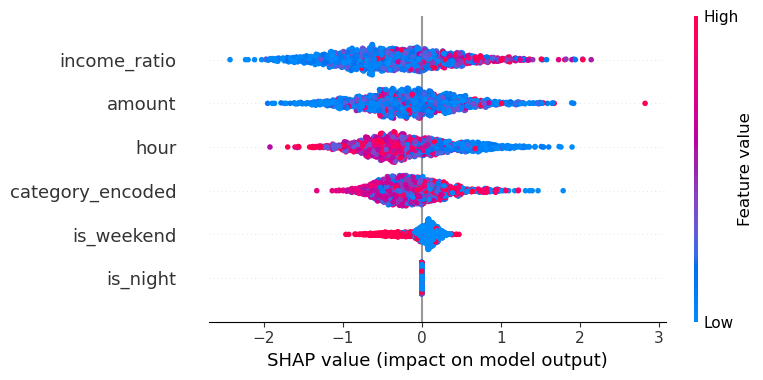

In [69]:
shap.summary_plot(shap_values, X_test)

In [ ]:
#The SHAP summary plot shows that income_ratio is the most important feature, followed by amount and transaction hour. Merchant category has a moderate influence, while weekend and night transactions contribute very little to the model's predictions.

Final Conclusion

Among all methods, Logistic Regression performed best for fraud detection because it achieved the highest recall (48%), detecting the largest number of fraudulent transactions. Although its overall accuracy was lower, recall is the most important metric in fraud detection since missing fraudulent transactions (False Negatives) is much more costly than generating false alarms (False Positives).

Why not Random Forest or XGBoost?

Random Forest and XGBoost achieved high accuracy (94% and 93%), but they detected almost no fraud cases due to the severe class imbalance. Therefore, they are not suitable for this fraud detection task without additional techniques such as resampling or parameter tuning.

In banking, minimizing False Negatives is more important than maximizing accuracy because undetected fraud can lead to significant financial losses. Therefore, Logistic Regression is the preferred model for this dataset.